# Chapter 1: Research and Development

AI Index Report 2025

## Loading data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

In [ ]:
import kagglehub

path = kagglehub.dataset_download("paultimothymooney/ai-index-report-2025")
print("Path to dataset files:", path)

/home/mathew/repos/mie1624-group/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/mathew/.cache/kagglehub/datasets/paultimothymooney/ai-index-report-2025/versions/1


In [ ]:
import os

data_folder = os.path.join(path, "PUBLIC DATA_ 2025 AI Index Report", "1. Research and Development", "Data")
print("Available files:")
sorted(os.listdir(data_folder))

Available files:


['fig_1.1.1.csv',
 'fig_1.1.10.csv',
 'fig_1.1.11.csv',
 'fig_1.1.12.csv',
 'fig_1.1.13.csv',
 'fig_1.1.2.csv',
 'fig_1.1.3.csv',
 'fig_1.1.4.csv',
 'fig_1.1.5.csv',
 'fig_1.1.6.csv',
 'fig_1.1.7.csv',
 'fig_1.1.8.csv',
 'fig_1.1.9.csv',
 'fig_1.2.1.csv',
 'fig_1.2.2.csv',
 'fig_1.2.3.csv',
 'fig_1.2.4.csv',
 'fig_1.2.5.csv',
 'fig_1.3.1.csv',
 'fig_1.3.10.csv',
 'fig_1.3.11.csv',
 'fig_1.3.12.csv',
 'fig_1.3.13.csv',
 'fig_1.3.14.csv',
 'fig_1.3.15.csv',
 'fig_1.3.16.csv',
 'fig_1.3.17.csv',
 'fig_1.3.18.csv',
 'fig_1.3.19.csv',
 'fig_1.3.2.csv',
 'fig_1.3.20.csv',
 'fig_1.3.21.csv',
 'fig_1.3.22.csv',
 'fig_1.3.23.csv',
 'fig_1.3.24.csv',
 'fig_1.3.25.csv',
 'fig_1.3.26.csv',
 'fig_1.3.3.csv',
 'fig_1.3.4.csv',
 'fig_1.3.5.csv',
 'fig_1.3.6.csv',
 'fig_1.3.7.csv',
 'fig_1.3.8.csv',
 'fig_1.3.9.csv',
 'fig_1.4.1.csv',
 'fig_1.4.2.csv',
 'fig_1.4.3.csv',
 'fig_1.4.4.csv',
 'fig_1.4.5.csv',
 'fig_1.4.6.csv',
 'fig_1.4.7.csv',
 'fig_1.4.8.csv',
 'fig_1.5.1.csv',
 'fig_1.5.2.csv',
 'fig_1

In [ ]:
# Load all Chapter 1 datasets
def load(fig_name):
    return pd.read_csv(os.path.join(data_folder, fig_name))

# 1.1 Publications
pub_total = load("fig_1.1.1.csv")           # Total AI publications worldwide
pub_pct_cs = load("fig_1.1.2.csv")          # AI as % of CS publications
pub_venue = load("fig_1.1.3.csv")           # Publications by venue type
pub_region = load("fig_1.1.4.csv")          # Publications by region
pub_citations_region = load("fig_1.1.5.csv") # Citations by region
pub_country = load("fig_1.1.6.csv")         # Publications by country
pub_citations_country = load("fig_1.1.7.csv") # Citations by country
pub_sector = load("fig_1.1.8.csv")          # Publications by sector
pub_sector_country = load("fig_1.1.9.csv")  # Publications by sector & country 2023
pub_topic = load("fig_1.1.10.csv")          # Publications by topic
top100_country = load("fig_1.1.11.csv")     # Top 100 cited papers by country
top100_sector = load("fig_1.1.12.csv")      # Top 100 cited papers by sector
top100_org = load("fig_1.1.13.csv")         # Top 100 cited papers by organization

# 1.2 Patents
pat_total = load("fig_1.2.1.csv")           # Total AI patents worldwide
pat_region = load("fig_1.2.2.csv")          # Patents by region
pat_country = load("fig_1.2.3.csv")         # Patents by country
pat_per_capita = load("fig_1.2.4.csv")      # Patents per 100K inhabitants
pat_growth = load("fig_1.2.5.csv")          # Patent growth % change

# 1.3 Notable AI Models
models_2024 = load("fig_1.3.1.csv")         # Notable models by country 2024
models_time = load("fig_1.3.2.csv")         # Notable models over time by country
models_sector = load("fig_1.3.4.csv")       # Notable models by sector
models_sector_pct = load("fig_1.3.5.csv")   # Notable models by sector (%)
models_org_2024 = load("fig_1.3.6.csv")     # Notable models by organization 2024
models_access = load("fig_1.3.8.csv")       # Notable models by access type
models_access_pct = load("fig_1.3.9.csv")   # Notable models by access type (%)
models_code_access = load("fig_1.3.10.csv") # Notable models by training code access type

print("All datasets loaded successfully.")

All datasets loaded successfully.


---
## AI Publications Analysis


### Global AI Publication Growth

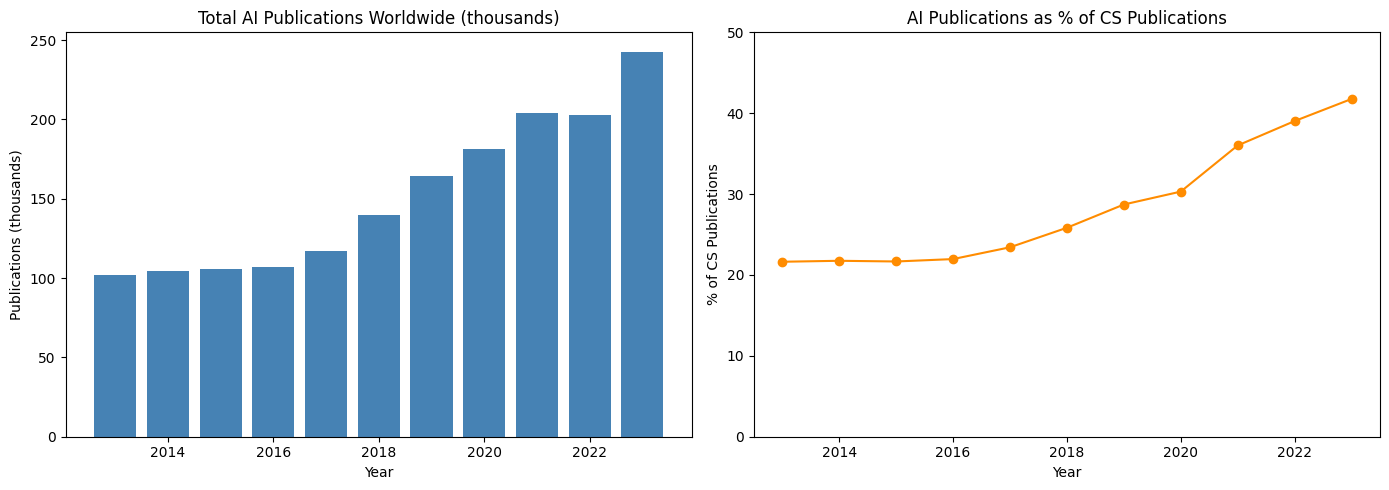

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total publications
axes[0].bar(pub_total["Year"], pub_total.iloc[:, 1], color="steelblue")
axes[0].set_title("Total AI Publications Worldwide (thousands)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Publications (thousands)")

# AI as % of CS
axes[1].plot(pub_pct_cs["Year"], pub_pct_cs.iloc[:, 1] * 100, marker="o", color="darkorange")
axes[1].set_title("AI Publications as % of CS Publications")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% of CS Publications")
axes[1].set_ylim(0, 50)

plt.tight_layout()
plt.show()

AI publications have more than doubled from ~102K in 2013 to ~243K in 2023, now representing 41.8% of all computer science publications. This rapid growth reflects the increasing centrality of AI across the research landscape.

### Publications by Country

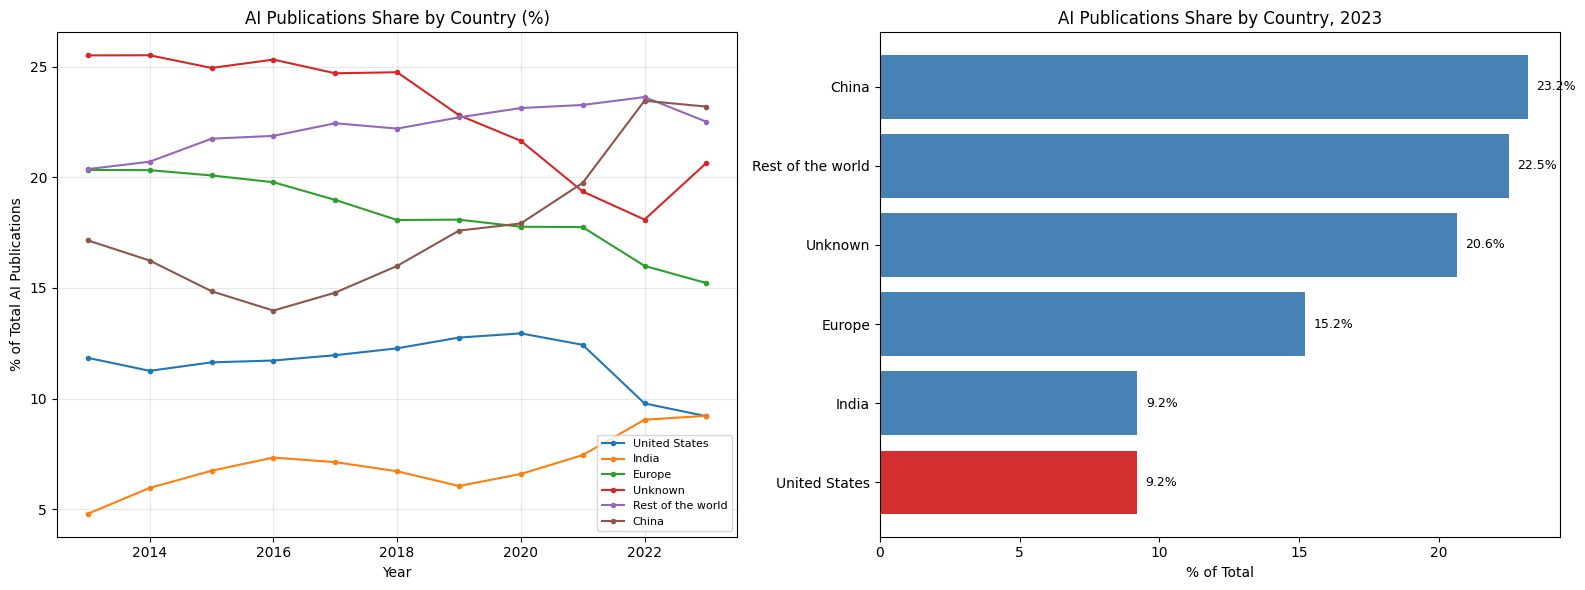

In [ ]:
# Publications share by country over time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label in pub_country["Label"].unique():
    subset = pub_country[pub_country["Label"] == label]
    axes[0].plot(subset["Year"], subset.iloc[:, 1] * 100, marker=".", label=label)

axes[0].set_title("AI Publications Share by Country (%)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("% of Total AI Publications")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Latest year snapshot
latest_pub = pub_country[pub_country["Year"] == 2023].copy()
latest_pub["pct"] = latest_pub.iloc[:, 1] * 100
latest_pub = latest_pub.sort_values("pct", ascending=True)

colors = ["#d32f2f" if label == "United States" else "steelblue" for label in latest_pub["Label"]]
axes[1].barh(latest_pub["Label"], latest_pub["pct"], color=colors)
axes[1].set_title("AI Publications Share by Country, 2023")
axes[1].set_xlabel("% of Total")

for i, (val, label) in enumerate(zip(latest_pub["pct"], latest_pub["Label"])):
    axes[1].text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

China leads in AI publication volume at 23.2%, followed by India (9.2%) and the United States (9.2%). Notably, **Canada is not tracked as a separate country** in this dataset. It falls under the broader "Rest of the world" or regional categories. **Finding:** Canada's individual publication share is too small to be highlighted separately by the AI Index, unlike China, India, the US, and Europe.

### Citations by Country

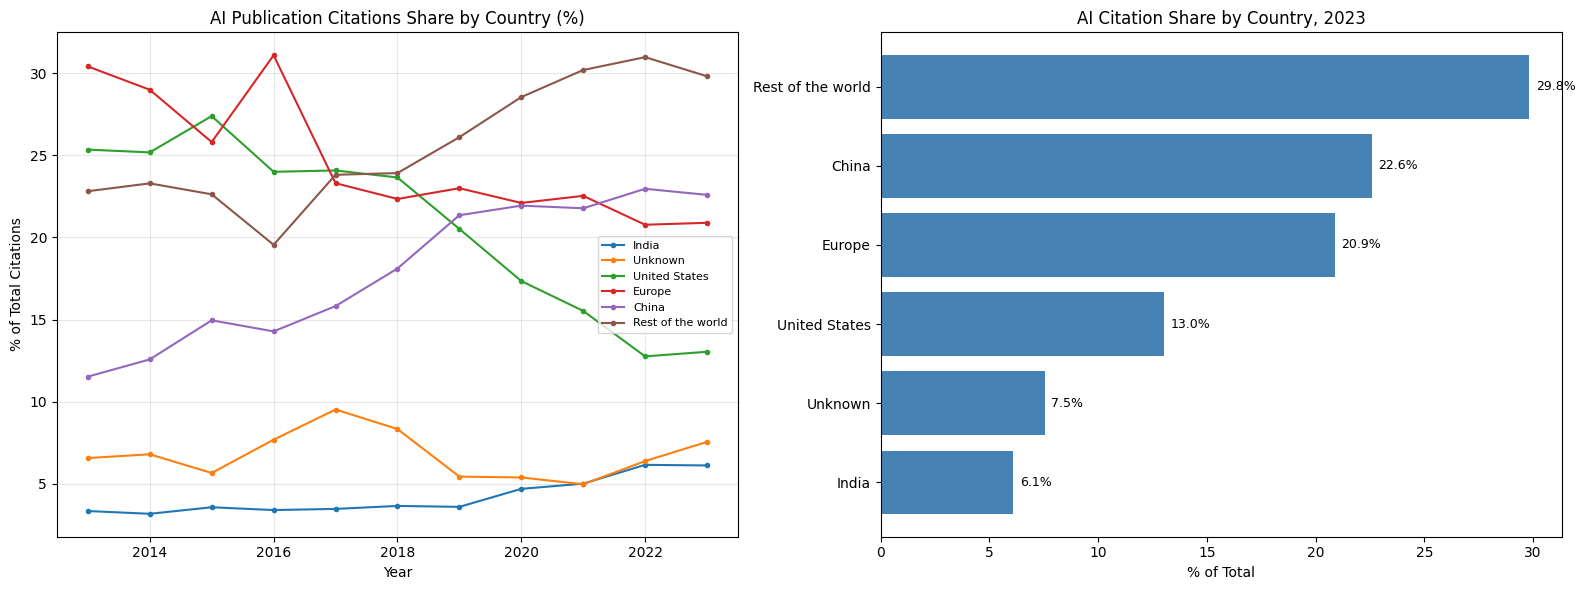

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label in pub_citations_country["Label"].unique():
    subset = pub_citations_country[pub_citations_country["Label"] == label]
    axes[0].plot(subset["Year"], subset.iloc[:, 1] * 100, marker=".", label=label)

axes[0].set_title("AI Publication Citations Share by Country (%)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("% of Total Citations")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Latest year snapshot
latest_cit = pub_citations_country[pub_citations_country["Year"] == 2023].copy()
latest_cit["pct"] = latest_cit.iloc[:, 1] * 100
latest_cit = latest_cit.sort_values("pct", ascending=True)

axes[1].barh(latest_cit["Label"], latest_cit["pct"], color="steelblue")
axes[1].set_title("AI Citation Share by Country, 2023")
axes[1].set_xlabel("% of Total")

for i, (val, label) in enumerate(zip(latest_cit["pct"], latest_cit["Label"])):
    axes[1].text(val + 0.3, i, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

China leads in citation share (22.6%), followed by Europe (20.9%) and the United States (13.0%). The late 2010s marked a turning point when China surpassed both Europe and the US in citation volume. The US share of citations has declined from ~30% in 2013 to 13% in 2023.

### Top 100 Most-Cited AI Publications

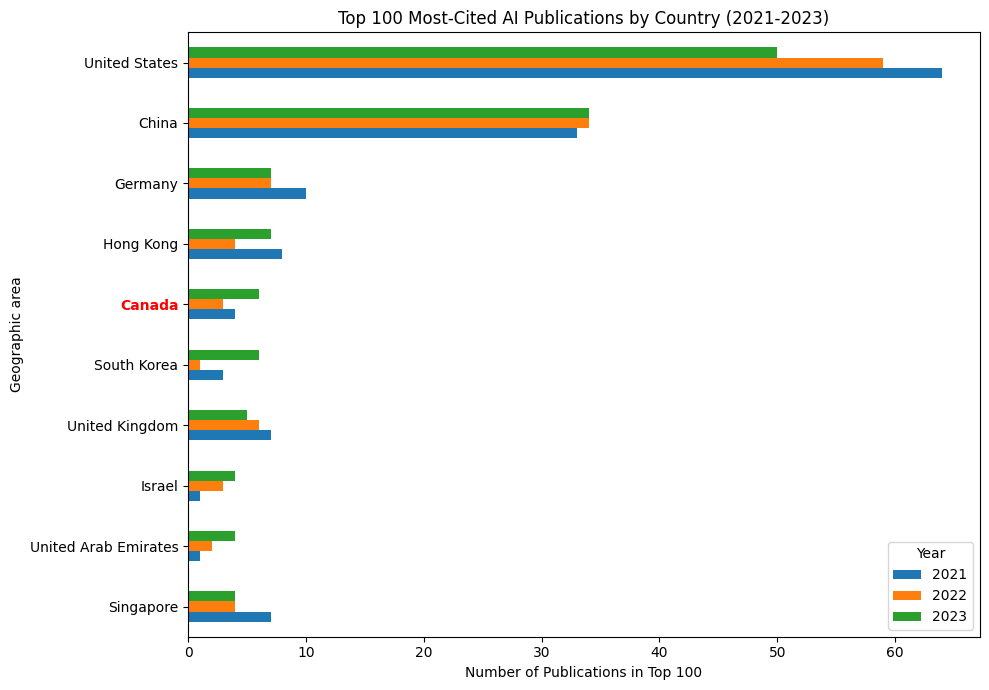

In [ ]:
# Pivot for grouped bar chart
top100_pivot = top100_country.pivot_table(
    index="Geographic area",
    columns="Label",
    values="Number of highly cited publications in top 100",
    fill_value=0
)

# Sort by 2023 values
top100_pivot = top100_pivot.sort_values(2023, ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
top100_pivot.plot(kind="barh", ax=ax)

# Highlight Canada
y_labels = ax.get_yticklabels()
for label in y_labels:
    if label.get_text() == "Canada":
        label.set_fontweight("bold")
        label.set_color("red")

ax.set_title("Top 100 Most-Cited AI Publications by Country (2021-2023)")
ax.set_xlabel("Number of Publications in Top 100")
ax.legend(title="Year")
plt.tight_layout()
plt.show()

In [ ]:
# Canada's position in top 100
canada_top100 = top100_country[top100_country["Geographic area"] == "Canada"]
print("Canada's Top 100 Most-Cited AI Publications:")
print(canada_top100.to_string(index=False))
print()

# Compute Canada's rank each year
for year in [2021, 2022, 2023]:
    year_data = top100_country[top100_country["Label"] == year].sort_values(
        "Number of highly cited publications in top 100", ascending=False
    ).reset_index(drop=True)
    year_data["Rank"] = range(1, len(year_data) + 1)
    canada_rank = year_data[year_data["Geographic area"] == "Canada"]["Rank"].values[0]
    canada_count = year_data[year_data["Geographic area"] == "Canada"].iloc[0, 0]
    print(f"{year}: Canada ranked #{canada_rank} with {canada_count} papers in top 100")

Canada's Top 100 Most-Cited AI Publications:
 Number of highly cited publications in top 100 Geographic area  Label
                                              6          Canada   2023
                                              3          Canada   2022
                                              4          Canada   2021

2021: Canada ranked #7 with 4 papers in top 100
2022: Canada ranked #7 with 3 papers in top 100
2023: Canada ranked #5 with 6 papers in top 100


Despite not appearing as a separate country in overall publication data, Canada does show up in the **top 100 most-cited publications**, with 4 papers (2021), 3 papers (2022), and 6 papers (2023). This indicates that while Canada's total output is small, its research quality and impact are relatively strong. A pattern consistent with Canada's strength in academic AI research led by institutions like the University of Toronto, Mila, and the University of Montreal.

### Publications by Sector

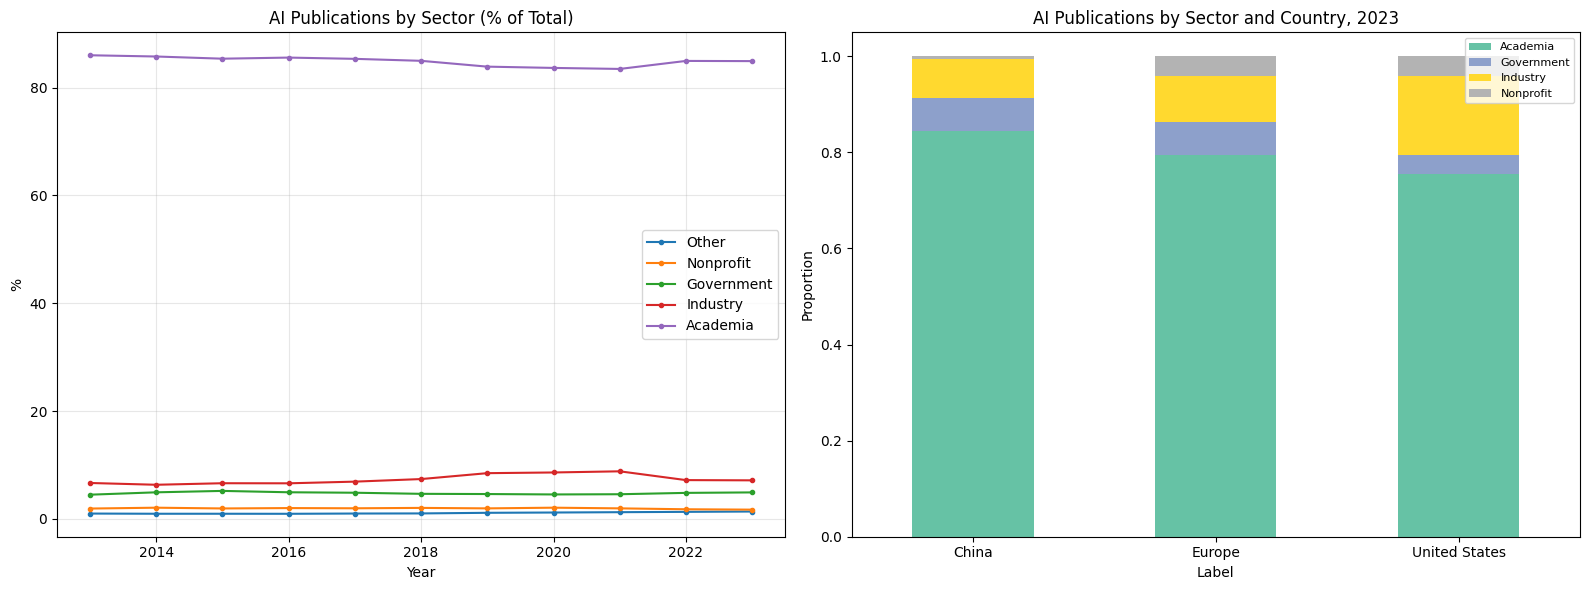

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sector trends over time
for label in pub_sector["Label"].unique():
    subset = pub_sector[pub_sector["Label"] == label]
    axes[0].plot(subset["Year"], subset.iloc[:, 1] * 100, marker=".", label=label)

axes[0].set_title("AI Publications by Sector (% of Total)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("%")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sector breakdown by country (2023)
sector_pivot = pub_sector_country.pivot_table(
    index="Label", columns="Sector", values="AI Publications (% of Total)"
).fillna(0)

sector_pivot.plot(kind="bar", stacked=True, ax=axes[1], colormap="Set2")
axes[1].set_title("AI Publications by Sector and Country, 2023")
axes[1].set_ylabel("Proportion")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

Academia dominates AI publications globally (84.9% in 2023). However, the US has a notably higher industry contribution (16.5%) compared to China (8.0%). This gap highlights that US industry is more actively publishing AI research, which may correlate with stronger industry-academia collaboration and commercialization of AI.

### Publications by Topic

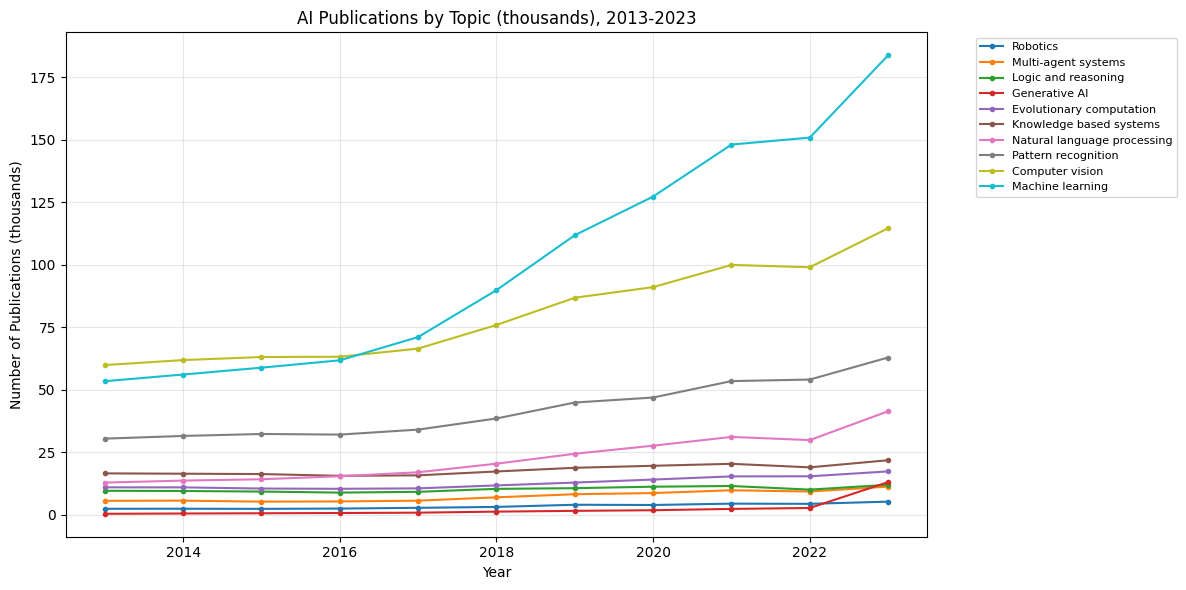

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

for label in pub_topic["Label"].unique():
    subset = pub_topic[pub_topic["Label"] == label]
    ax.plot(subset["Year"], subset.iloc[:, 1], marker=".", label=label)

ax.set_title("AI Publications by Topic (thousands), 2013-2023")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Publications (thousands)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Machine learning is the dominant research topic (75.7% of AI publications in 2023), followed by computer vision (47.2%) and pattern recognition (25.9%). Generative AI publications have seen a sharp increase in recent years, reflecting the post-ChatGPT surge of interest.

---
## AI Patents Analysis

Patents are a measure of commercial R&D and innovation. We examine patent volume, geographic distribution, and per-capita patent intensity.

### Global AI Patent Growth

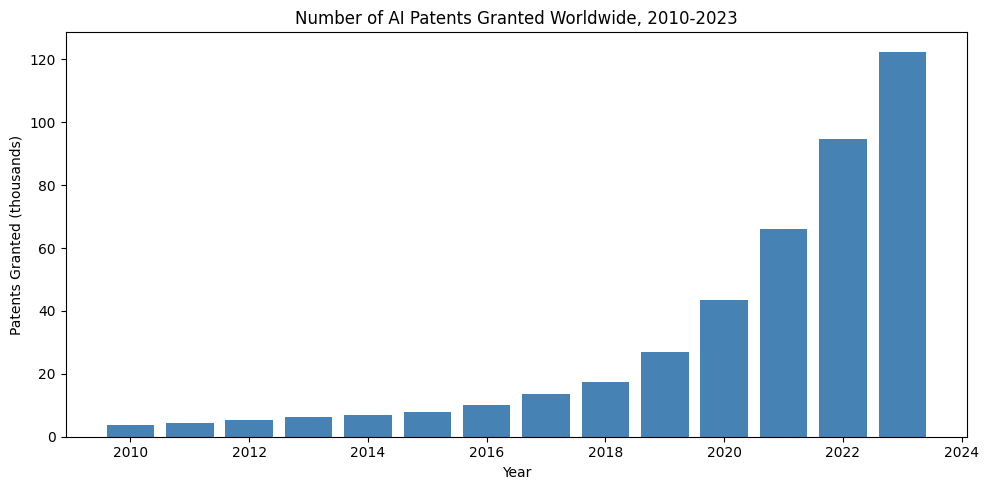

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(pat_total["Year"], pat_total.iloc[:, 1], color="steelblue")
ax.set_title("Number of AI Patents Granted Worldwide, 2010-2023")
ax.set_xlabel("Year")
ax.set_ylabel("Patents Granted (thousands)")
plt.tight_layout()
plt.show()

AI patents grew from ~3.8K in 2010 to ~122.5K in 2023, a roughly 32x increase over 13 years. The growth has been especially sharp since 2018, driven primarily by China's massive expansion in AI patenting.

### Patents by Country

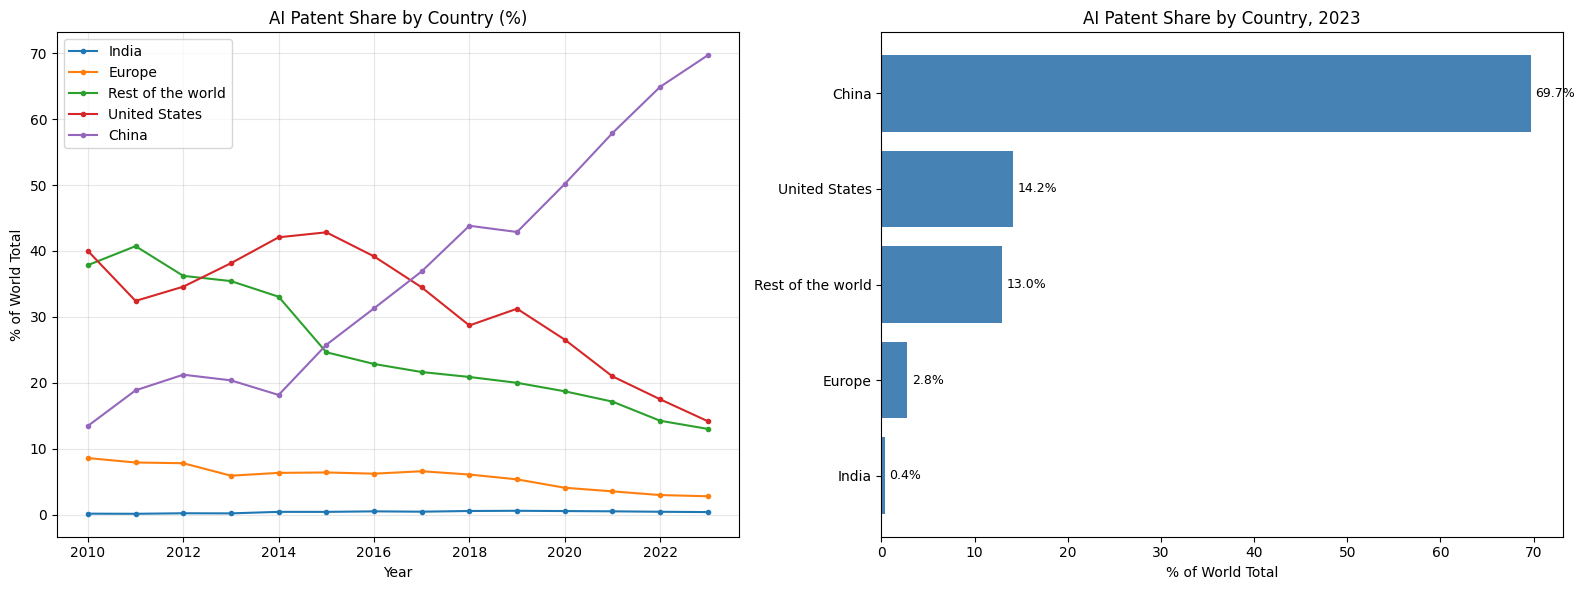

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Patent share over time
for label in pat_country["Label"].unique():
    subset = pat_country[pat_country["Label"] == label]
    axes[0].plot(subset["Year"], subset.iloc[:, 1] * 100, marker=".", label=label)

axes[0].set_title("AI Patent Share by Country (%)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("% of World Total")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Latest year snapshot
latest_pat = pat_country[pat_country["Year"] == 2023].copy()
latest_pat["pct"] = latest_pat.iloc[:, 1] * 100
latest_pat = latest_pat.sort_values("pct", ascending=True)

axes[1].barh(latest_pat["Label"], latest_pat["pct"], color="steelblue")
axes[1].set_title("AI Patent Share by Country, 2023")
axes[1].set_xlabel("% of World Total")

for i, (val, label) in enumerate(zip(latest_pat["pct"], latest_pat["Label"])):
    axes[1].text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

China dominates AI patenting at 69.7% of the world total in 2023, followed by the United States at 14.2%. Europe (2.8%), India (0.4%), and the rest of the world collectively account for a small share. **Canada is not individually tracked** in the patent data, falling under the broader categories indicating negligible patent output.

### Patents Per Capita

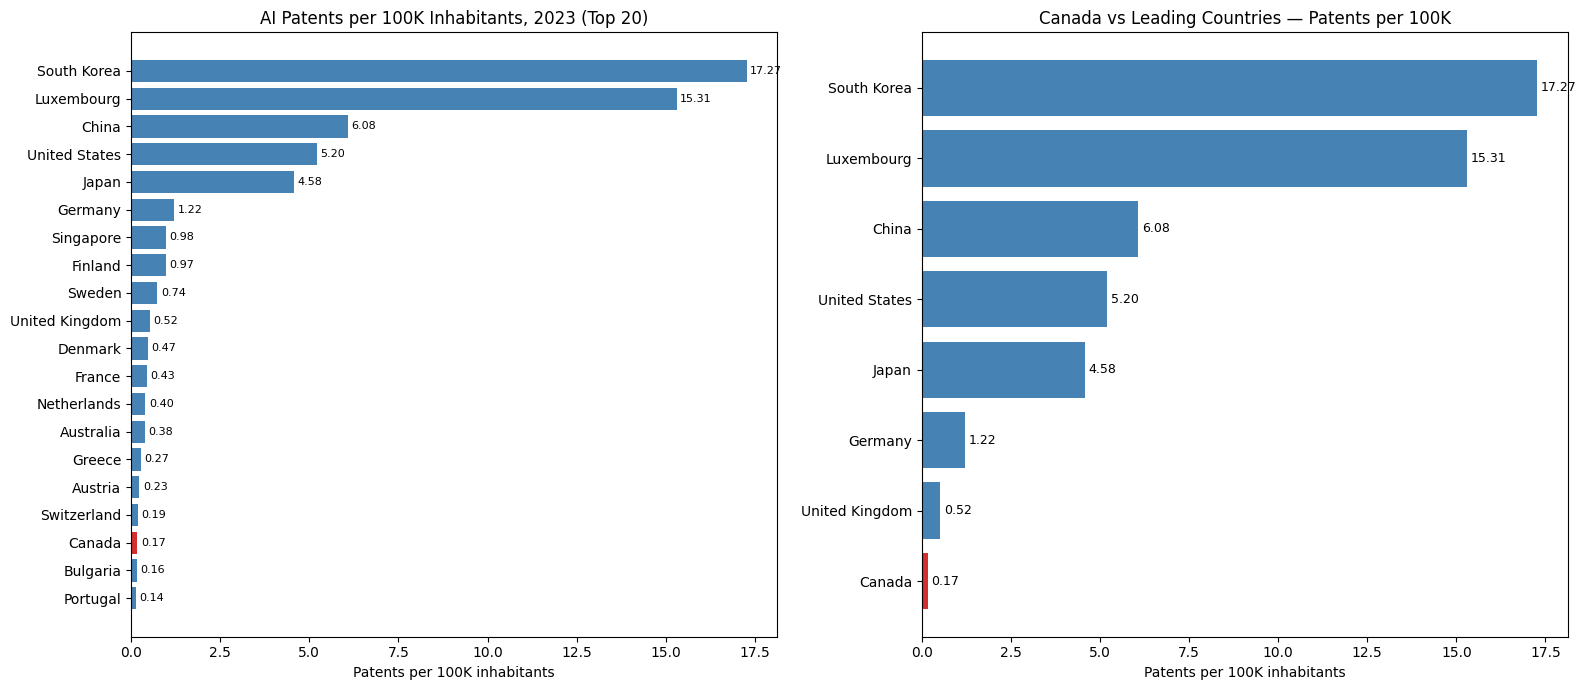

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 20 countries by patents per capita
top20_pat = pat_per_capita.head(20).sort_values(pat_per_capita.columns[1], ascending=True)

colors = ["#d32f2f" if c == "Canada" else "steelblue" for c in top20_pat["Geographic Area"]]
axes[0].barh(top20_pat["Geographic Area"], top20_pat.iloc[:, 1], color=colors)
axes[0].set_title("AI Patents per 100K Inhabitants, 2023 (Top 20)")
axes[0].set_xlabel("Patents per 100K inhabitants")

for i, (val, area) in enumerate(zip(top20_pat.iloc[:, 1], top20_pat["Geographic Area"])):
    axes[0].text(val + 0.1, i, f"{val:.2f}", va="center", fontsize=8)

# Canada's rank
pat_per_capita_sorted = pat_per_capita.sort_values(pat_per_capita.columns[1], ascending=False).reset_index(drop=True)
pat_per_capita_sorted["Rank"] = range(1, len(pat_per_capita_sorted) + 1)
canada_pat = pat_per_capita_sorted[pat_per_capita_sorted["Geographic Area"] == "Canada"]

# Show Canada vs top countries
compare_countries = ["South Korea", "Luxembourg", "China", "United States", "Japan",
                     "Germany", "United Kingdom", "Canada"]
compare_data = pat_per_capita[pat_per_capita["Geographic Area"].isin(compare_countries)]
compare_data = compare_data.sort_values(compare_data.columns[1], ascending=True)

colors2 = ["#d32f2f" if c == "Canada" else "steelblue" for c in compare_data["Geographic Area"]]
axes[1].barh(compare_data["Geographic Area"], compare_data.iloc[:, 1], color=colors2)
axes[1].set_title("Canada vs Leading Countries — Patents per 100K")
axes[1].set_xlabel("Patents per 100K inhabitants")

for i, (val, area) in enumerate(zip(compare_data.iloc[:, 1], compare_data["Geographic Area"])):
    axes[1].text(val + 0.1, i, f"{val:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

Canada ranks 18th globally in AI patents per capita at 0.17 per 100K inhabitants, roughly **30x lower than South Korea** (17.27) and **30x lower than the United States** (5.20). This is a critical gap: while Canada has strong AI research talent, it is not translating research into patents and commercial IP at anywhere near the rate of leading countries.

---
## Notable AI Models

Notable AI models represent the most impactful machine learning systems. This section examines which countries and organizations are producing them.

### Notable Models by Country (2024)

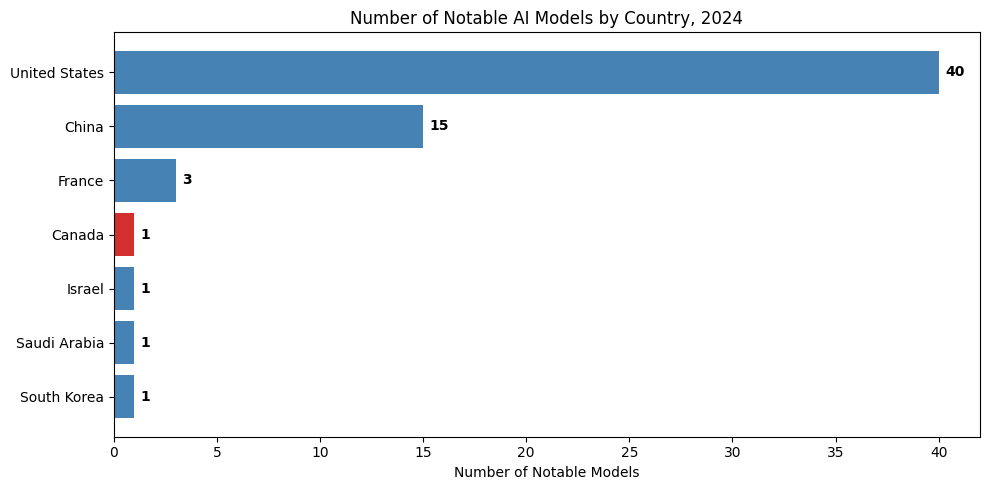

In [ ]:
models_sorted = models_2024.sort_values(models_2024.columns[0], ascending=True)

colors = ["#d32f2f" if c == "Canada" else "steelblue" for c in models_sorted["Geographic area"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(models_sorted["Geographic area"], models_sorted.iloc[:, 0], color=colors)
ax.set_title("Number of Notable AI Models by Country, 2024")
ax.set_xlabel("Number of Notable Models")

for i, (val, area) in enumerate(zip(models_sorted.iloc[:, 0], models_sorted["Geographic area"])):
    ax.text(val + 0.3, i, str(val), va="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

In 2024, the United States produced 40 notable AI models, China produced 15, and France produced 3. Canada produced only 1 notable AI model. The US produces 40x more notable AI models than Canada.

### Notable Models Over Time

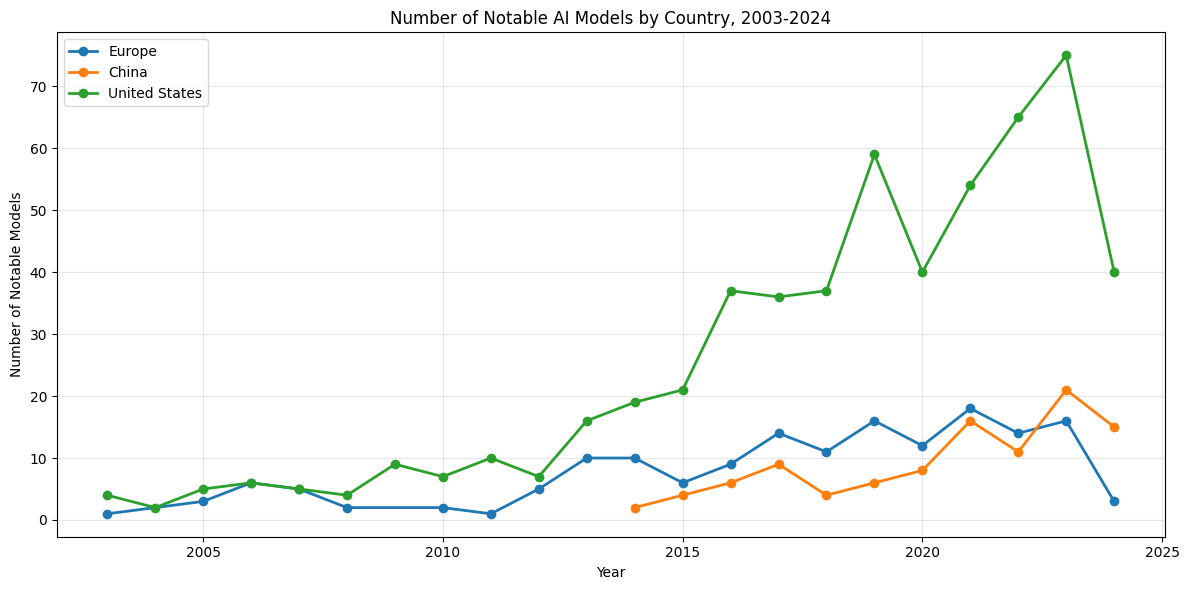

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

for label in models_time["Label"].unique():
    subset = models_time[models_time["Label"] == label]
    ax.plot(subset["Year"], subset.iloc[:, 1], marker="o", label=label, linewidth=2)

ax.set_title("Number of Notable AI Models by Country, 2003-2024")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Notable Models")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The United States has consistently led in notable AI model production, with a dramatic acceleration since 2020. China has grown significantly but remains well behind the US. Europe's contribution remains relatively small. Canada is not separately tracked in this time series, consistent with its minimal contribution.

### Industry vs Academia in Model Development

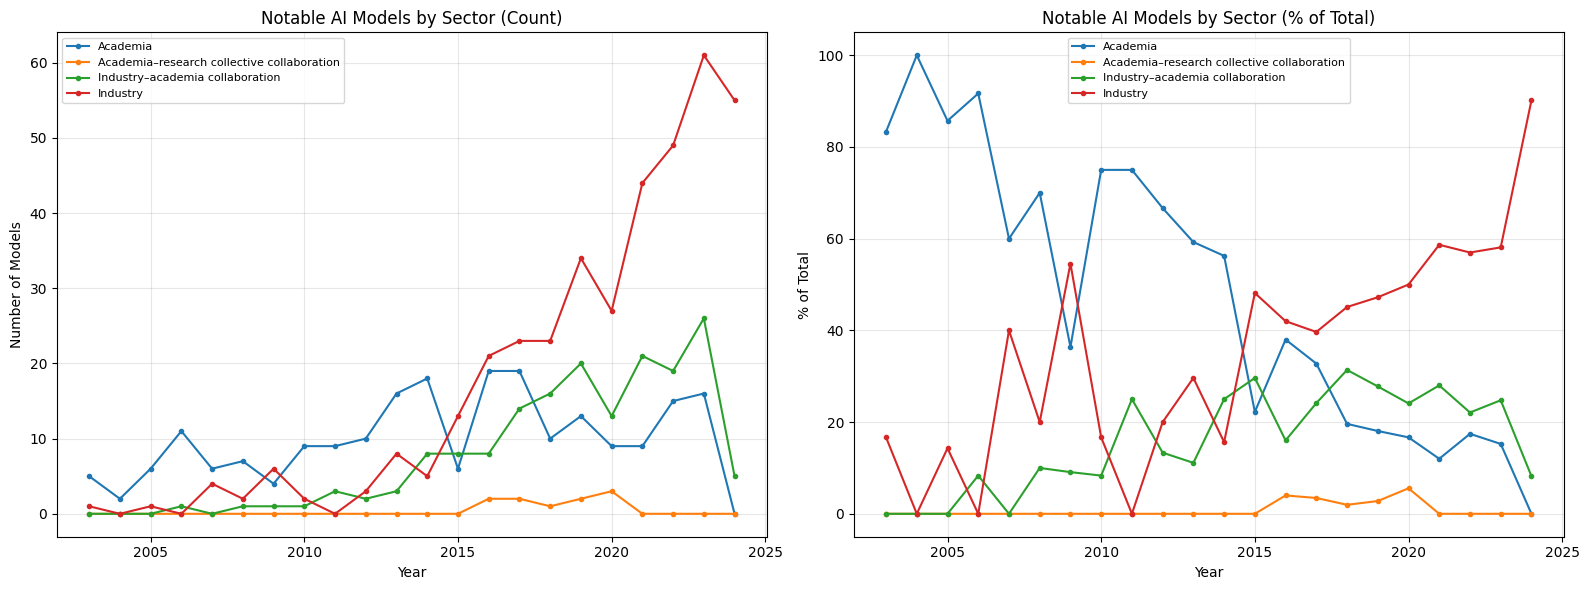

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute numbers
for label in models_sector["Label"].unique():
    subset = models_sector[models_sector["Label"] == label]
    if subset.iloc[:, 1].sum() > 5:  # Only plot significant sectors
        axes[0].plot(subset["Year"], subset.iloc[:, 1], marker=".", label=label)

axes[0].set_title("Notable AI Models by Sector (Count)")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Models")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Percentage
for label in models_sector_pct["Label"].unique():
    subset = models_sector_pct[models_sector_pct["Label"] == label].copy()
    subset["pct"] = subset.iloc[:, 1].astype(str).str.rstrip("%").astype(float)
    if subset["pct"].max() > 5:
        axes[1].plot(subset["Year"], subset["pct"], marker=".", label=label)

axes[1].set_title("Notable AI Models by Sector (% of Total)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("% of Total")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Industry now dominates notable AI model production, accounting for 90.2% in 2024. Until 2014, academia led model development, but the shift to industry has been dramatic. In 2024, Epoch AI identified 0 notable models from academia alone. This highlights that frontier AI model development now requires massive compute and data resources only available to large companies. For Canada, this means that relying solely on academic research will not produce globally competitive AI systems, **industry R&D investment is essential**.

### Open-Source vs Closed-Source: China vs the United States

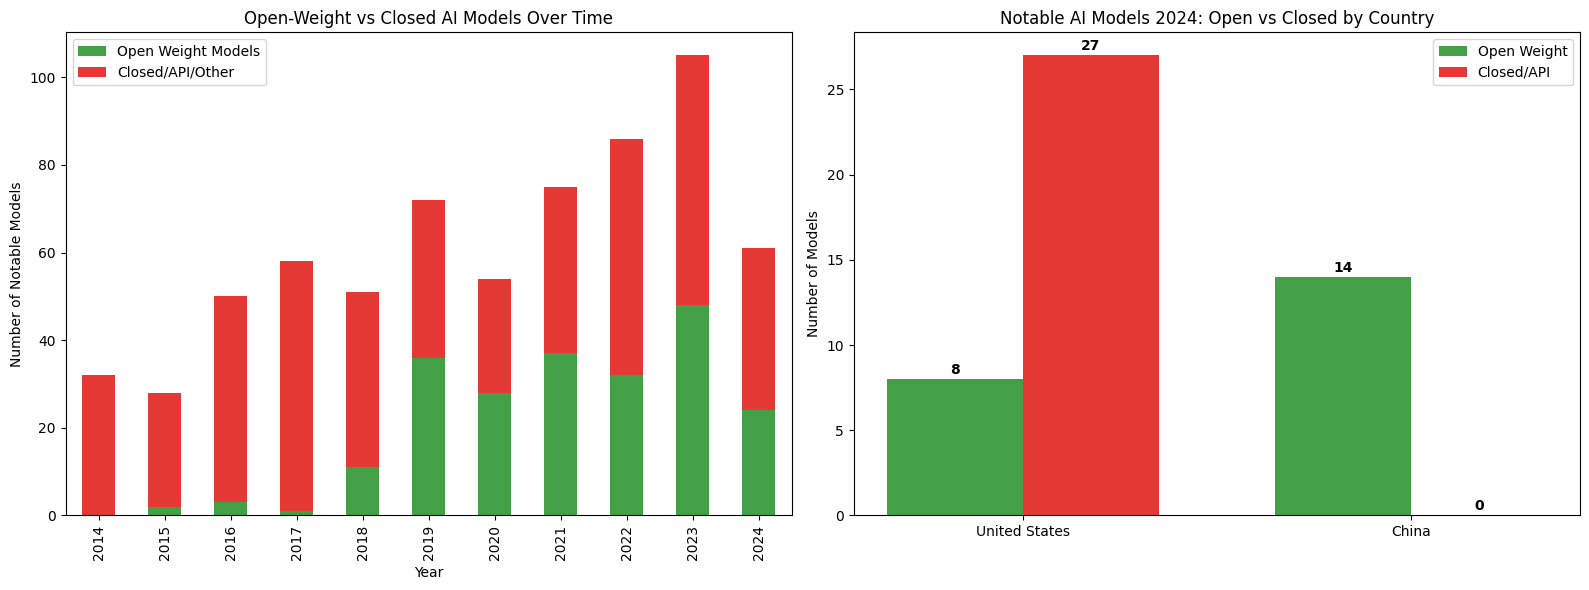

In [ ]:
# Model access type trends over time
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Access type counts over time (stacked bar)
access_pivot = models_access.pivot_table(
    index="Year", columns="Model Accessibility",
    values="Number of notable AI models", fill_value=0
)

# Group into Open vs Closed/Restricted
open_cols = [c for c in access_pivot.columns if "Open" in c or "open" in c]
closed_cols = [c for c in access_pivot.columns if c not in open_cols]

access_pivot["Open Weight Models"] = access_pivot[open_cols].sum(axis=1)
access_pivot["Closed/API/Other"] = access_pivot[closed_cols].sum(axis=1)

access_pivot[["Open Weight Models", "Closed/API/Other"]].plot(
    kind="bar", stacked=True, ax=axes[0], color=["#43a047", "#e53935"]
)
axes[0].set_title("Open-Weight vs Closed AI Models Over Time")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Number of Notable Models")
axes[0].legend()

# Organizations by country affiliation
us_orgs = ["Google", "OpenAI", "Apple", "Meta", "Nvidia", "Anthropic",
           "Microsoft", "Writer", "UC Berkeley", "MIT"]
china_orgs = ["Alibaba", "ByteDance", "DeepSeek", "Tencent", "Zhipu AI"]

us_models = models_org_2024[models_org_2024["Organization"].isin(us_orgs)]
china_models = models_org_2024[models_org_2024["Organization"].isin(china_orgs)]

us_total = us_models.iloc[:, 1].sum()
china_total = china_models.iloc[:, 1].sum()

# Chinese notable models are predominantly open-weight (DeepSeek, Qwen/Alibaba, etc.)
# US models are predominantly API-access/closed (OpenAI, Anthropic, Google)
china_open = china_total  # DeepSeek, Alibaba Qwen, etc. are open-weight
china_closed = 0
us_open = 8   # Meta (4 - Llama), UC Berkeley (2), MIT (2) are open
us_closed = us_total - us_open  # Google, OpenAI, Anthropic, Apple, Nvidia, Writer are closed/API

categories = ["United States", "China"]
open_vals = [us_open, china_open]
closed_vals = [us_closed, china_closed]

x = np.arange(len(categories))
width = 0.35

axes[1].bar(x - width/2, open_vals, width, label="Open Weight", color="#43a047")
axes[1].bar(x + width/2, closed_vals, width, label="Closed/API", color="#e53935")
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories)
axes[1].set_title("Notable AI Models 2024: Open vs Closed by Country")
axes[1].set_ylabel("Number of Models")
axes[1].legend()

for i, (o, c) in enumerate(zip(open_vals, closed_vals)):
    axes[1].text(i - width/2, o + 0.3, str(o), ha="center", fontweight="bold")
    axes[1].text(i + width/2, c + 0.3, str(c), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

A key divergence in AI strategy between the US and China is their approach to model openness. **China's notable AI models are predominantly open-weight**, DeepSeek-V3, Alibaba's Qwen series, and others release model weights publicly. In contrast, **US companies largely compete through proprietary, closed-source models** accessible only via API (OpenAI's GPT, Anthropic's Claude, Google's Gemini).

This dynamic has an important effect on publication and citation metrics: because US companies treat their models as competitive IP, they publish fewer technical details. China's open-source approach means more publications, more citations, and broader global adoption of Chinese AI technology. The exception is Meta, which releases open-weight models (Llama series) and is the most prolific US publisher.

**Implication for Canada:** Canada could adopt an open-source-first AI strategy, similar to China's approach, to maximize the global impact of its research output and attract international collaboration. Open-weight models from Canadian institutions could serve as a force multiplier for Canada's relatively small but high-quality AI research base.

---
## R&D Composite Score & Country Ranking

Construct an R&D-focused composite score combining multiple indicators to rank countries and analyze Canada's competitive position.

### Building the R&D Score

In [ ]:
# Load Tortoise Media AI Index data (used by other group members)
# This dataset contains R&D-related scores for 62 countries
import kagglehub

ai_index_path = kagglehub.dataset_download("katerynameleshenko/ai-index")
ai_index_df = pd.read_csv(os.path.join(ai_index_path, "AI_index_db.csv"))

print(f"Countries in dataset: {len(ai_index_df)}")
print(f"\nColumns: {list(ai_index_df.columns)}")
ai_index_df.head()

Countries in dataset: 62

Columns: ['Country', 'Talent', 'Infrastructure', 'Operating Environment', 'Research', 'Development', 'Government Strategy', 'Commercial', 'Total score', 'Region', 'Cluster', 'Income group', 'Political regime']


,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy


In [ ]:
# Select R&D-relevant features from Tortoise Media data
rd_features = ["Research", "Development", "Talent", "Infrastructure"]

# Create weighted R&D score
rd_weights = {
    "Research": 0.35,
    "Development": 0.30,
    "Talent": 0.20,
    "Infrastructure": 0.15
}

ai_index_df["RD_Score"] = sum(
    ai_index_df[col] * weight for col, weight in rd_weights.items()
)

# Add patents per capita data
pat_per_capita_renamed = pat_per_capita.rename(columns={
    "Geographic Area": "Country",
    pat_per_capita.columns[1]: "Patents_Per_100K"
})

# Standardize country names for merging
name_map = {
    "United States of America": "United States",
    "The Netherlands": "Netherlands",
    "Czech Republic": "Czech Republic",
    "Slovak Republic": "Slovakia"
}
ai_index_df["Country_Merge"] = ai_index_df["Country"].replace(name_map)

rd_df = ai_index_df.merge(
    pat_per_capita_renamed, left_on="Country_Merge", right_on="Country",
    how="left", suffixes=("", "_pat")
)

# Add top 100 publications count (2023)
top100_2023 = top100_country[top100_country["Label"] == 2023][["Geographic area", "Number of highly cited publications in top 100"]]
top100_2023 = top100_2023.rename(columns={
    "Geographic area": "Country_Merge",
    "Number of highly cited publications in top 100": "Top100_Pubs"
})
top100_2023["Country_Merge"] = top100_2023["Country_Merge"].replace({
    "United States": "United States"
})

rd_df = rd_df.merge(top100_2023, on="Country_Merge", how="left")
rd_df["Top100_Pubs"] = rd_df["Top100_Pubs"].fillna(0)
rd_df["Patents_Per_100K"] = rd_df["Patents_Per_100K"].fillna(0)

# Add notable models 2024
models_renamed = models_2024.rename(columns={
    "Geographic area": "Country_Merge",
    models_2024.columns[0]: "Notable_Models_2024"
})

rd_df = rd_df.merge(models_renamed, on="Country_Merge", how="left")
rd_df["Notable_Models_2024"] = rd_df["Notable_Models_2024"].fillna(0)

print(f"Merged dataset: {len(rd_df)} countries")
rd_df[["Country", "Research", "Development", "Talent", "Infrastructure",
       "RD_Score", "Patents_Per_100K", "Top100_Pubs", "Notable_Models_2024"]].head(10)

Merged dataset: 62 countries


,Country,Research,Development,Talent,Infrastructure,RD_Score,Patents_Per_100K,Top100_Pubs,Notable_Models_2024
0,United States of America,100.00,100.00,100.00,94.02,99.1030,5.204606,50.0,40.0
1,China,71.42,79.97,16.51,100.00,67.2900,6.081548,34.0,15.0
2,United Kingdom,36.50,25.03,39.65,71.43,38.9285,0.517922,5.0,0.0
3,Canada,30.67,25.78,31.28,77.05,36.2820,0.174573,6.0,1.0
4,Israel,32.63,27.96,35.76,67.58,37.0975,0.122994,4.0,1.0
5,Singapore,37.67,22.55,39.38,84.30,40.4705,0.980119,4.0,0.0
6,South Korea,26.66,77.25,14.54,85.23,48.1985,17.268512,6.0,1.0
7,The Netherlands,25.54,30.17,33.83,81.99,37.0545,0.402750,0.0,0.0
8,Germany,35.84,24.79,27.63,77.22,37.0900,1.217579,7.0,0.0
9,France,25.48,21.44,28.32,77.15,32.5865,0.434926,0.0,3.0


In [ ]:
# Rank countries by R&D Score
rd_ranked = rd_df.sort_values("RD_Score", ascending=False).reset_index(drop=True)
rd_ranked["Rank"] = range(1, len(rd_ranked) + 1)

print("Country R&D Rankings:")
print(rd_ranked[["Rank", "Country", "RD_Score", "Research", "Development",
                 "Talent", "Infrastructure", "Patents_Per_100K",
                 "Top100_Pubs", "Notable_Models_2024"]].to_string(index=False))

Country R&D Rankings:
 Rank                  Country  RD_Score  Research  Development  Talent  Infrastructure  Patents_Per_100K  Top100_Pubs  Notable_Models_2024
    1 United States of America   99.1030    100.00       100.00  100.00           94.02          5.204606         50.0                 40.0
    2                    China   67.2900     71.42        79.97   16.51          100.00          6.081548         34.0                 15.0
    3              South Korea   48.1985     26.66        77.25   14.54           85.23         17.268512          6.0                  1.0
    4                Singapore   40.4705     37.67        22.55   39.38           84.30          0.980119          4.0                  0.0
    5           United Kingdom   38.9285     36.50        25.03   39.65           71.43          0.517922          5.0                  0.0
    6                Australia   38.3660     32.63        41.15   25.43           63.43          0.382611          0.0                  0.

In [ ]:
# Canada's R&D position
canada_row = rd_ranked[rd_ranked["Country"] == "Canada"]
canada_row[["Rank", "Country", "RD_Score", "Research", "Development",
            "Talent", "Infrastructure", "Patents_Per_100K",
            "Top100_Pubs", "Notable_Models_2024"]]

,Rank,Country,RD_Score,Research,Development,Talent,Infrastructure,Patents_Per_100K,Top100_Pubs,Notable_Models_2024
10,11,Canada,36.282,30.67,25.78,31.28,77.05,0.174573,6.0,1.0


### Country R&D Ranking Visualization

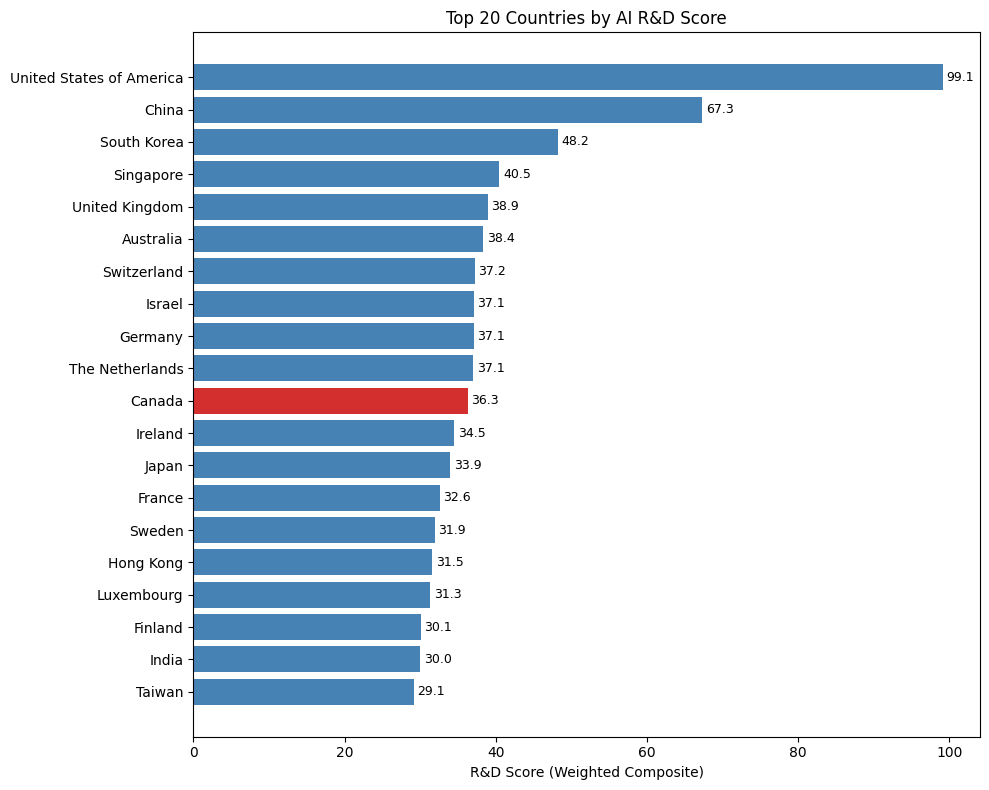

In [ ]:
# Top 20 countries by R&D Score
top20 = rd_ranked.head(20).sort_values("RD_Score", ascending=True)

colors = ["#d32f2f" if c == "Canada" else "steelblue" for c in top20["Country"]]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top20["Country"], top20["RD_Score"], color=colors)
ax.set_title("Top 20 Countries by AI R&D Score")
ax.set_xlabel("R&D Score (Weighted Composite)")

for i, (val, country) in enumerate(zip(top20["RD_Score"], top20["Country"])):
    ax.text(val + 0.5, i, f"{val:.1f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Spider Chart, Canada vs Leading Countries

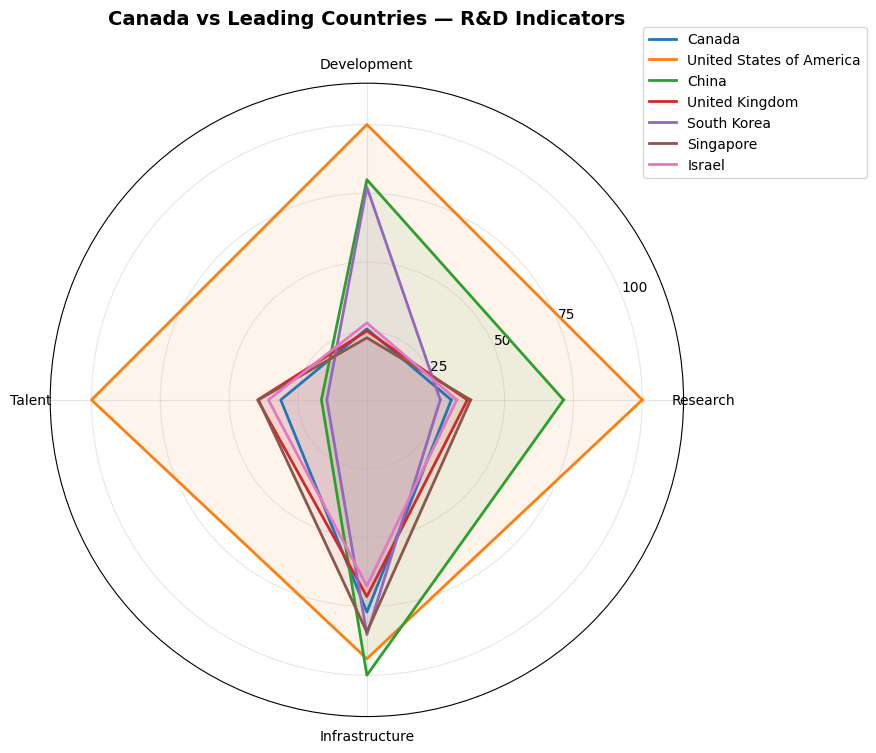

In [ ]:
def spider_plot(df, countries, features, title="Spider Chart", fill_alpha=0.08):
    angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

    for country in countries:
        row = df[df["Country"] == country]
        if row.empty:
            print(f"Country not found: {country}")
            continue
        values = row[features].iloc[0].astype(float).tolist()
        values += values[:1]
        ax.plot(angles, values, linewidth=2, label=country)
        ax.fill(angles, values, alpha=fill_alpha)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(features, fontsize=10)
    ax.set_title(title, y=1.08, fontsize=14, fontweight="bold")
    ax.set_ylim(0, 115)
    ax.set_yticks([25, 50, 75, 100])
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

spider_plot(
    ai_index_df,
    ["Canada", "United States of America", "China", "United Kingdom",
     "South Korea", "Singapore", "Israel"],
    rd_features,
    title="Canada vs Leading Countries — R&D Indicators"
)

### Gap Analysis, Canada vs USA

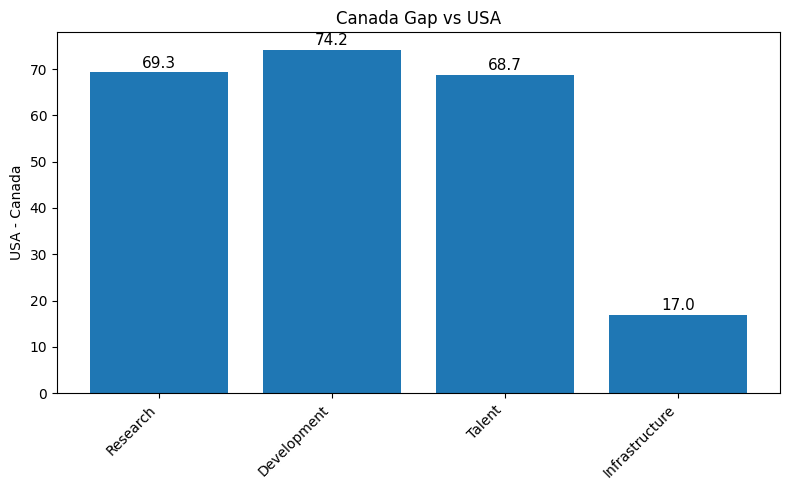

In [ ]:
canada_vals = ai_index_df[ai_index_df["Country"] == "Canada"][rd_features].values.flatten()
usa_vals = ai_index_df[ai_index_df["Country"] == "United States of America"][rd_features].values.flatten()

gap = usa_vals - canada_vals

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(rd_features, gap)
ax.set_title("Canada Gap vs USA")
ax.set_ylabel("USA - Canada")
plt.xticks(rotation=45, ha="right")

for i, val in enumerate(gap):
    ax.text(i, val + 1, f"{val:.1f}", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

The gap analysis reveals that Canada's largest R&D deficits relative to the US are in **Research** and **Development**, the two most heavily weighted factors. The Talent gap is moderate, and Infrastructure shows a smaller gap. This suggests that Canada's AI talent pipeline is a relative strength, but the country is underperforming in converting talent into research output and commercial development.

### Correlation Analysis

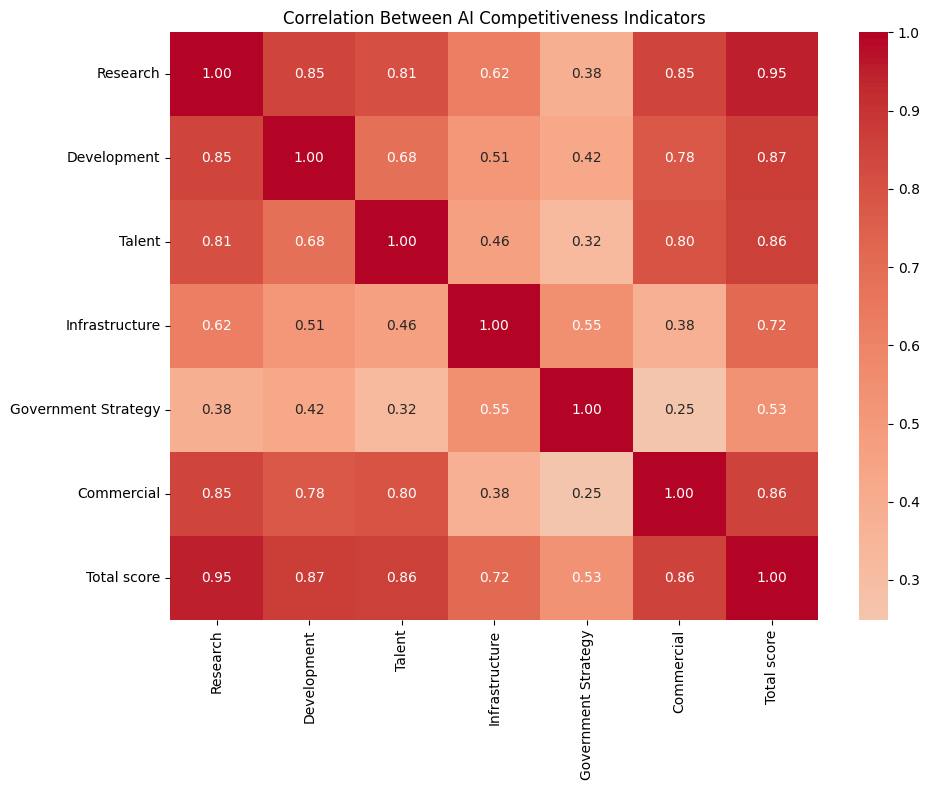

In [ ]:
corr_cols = ["Research", "Development", "Talent", "Infrastructure",
             "Government Strategy", "Commercial", "Total score"]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    ai_index_df[corr_cols].corr(),
    annot=True, cmap="coolwarm", center=0,
    fmt=".2f", ax=ax
)
ax.set_title("Correlation Between AI Competitiveness Indicators")
plt.tight_layout()
plt.show()

The correlation analysis shows that Research and Development are strongly correlated with overall AI competitiveness (Total score). Talent and Commercial scores also show high correlation. This confirms that R&D investment is a primary driver of national AI competitiveness.

### Canada's Enabling Conditions vs Innovation Output

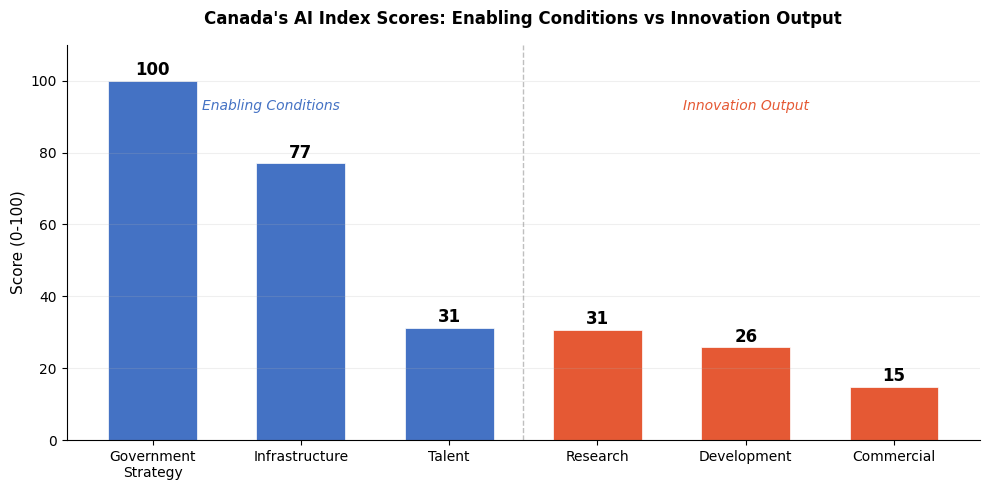

In [ ]:
# Canada's scores across all Tortoise Media AI Index indicators
canada_data = ai_index_df[ai_index_df["Country"] == "Canada"]

categories = ["Government\nStrategy", "Infrastructure", "Talent", "Research", "Development", "Commercial"]
score_cols = ["Government Strategy", "Infrastructure", "Talent", "Research", "Development", "Commercial"]
canada_scores = [canada_data[col].values[0] for col in score_cols]

fig, ax = plt.subplots(figsize=(10, 5))

# Enabling conditions (blue) vs innovation output (red)
colors = ["#4472C4", "#4472C4", "#4472C4", "#E55934", "#E55934", "#E55934"]

bars = ax.bar(categories, canada_scores, color=colors, width=0.6, edgecolor="white", linewidth=0.5)

for bar, val in zip(bars, canada_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{val:.0f}", ha="center", fontsize=12, fontweight="bold")

ax.axvline(x=2.5, color="gray", linestyle="--", linewidth=1, alpha=0.5)
ax.text(0.8, 92, "Enabling Conditions", ha="center", fontsize=10, color="#4472C4", fontstyle="italic")
ax.text(4.0, 92, "Innovation Output", ha="center", fontsize=10, color="#E55934", fontstyle="italic")

ax.set_ylabel("Score (0-100)", fontsize=11)
ax.set_title("Canada's AI Index Scores: Enabling Conditions vs Innovation Output",
             fontsize=12, fontweight="bold", pad=15)
ax.set_ylim(0, 110)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("canada_enabling_vs_output.png", dpi=200, bbox_inches="tight")
plt.show()

**Figure: Canada's AI Index Scores by Category.** Data from the Tortoise Media Global AI Index [1]. Blue bars represent enabling conditions (Government Strategy, Infrastructure, Talent); red bars represent innovation output (Research, Development, Commercial). Canada scores 100 on Government Strategy and 77 on Infrastructure, but drops sharply to 31, 26, and 15 on Research, Development, and Commercial respectively, indicating a gap between foundational readiness and downstream innovation capacity.

---
## Clustering Countries by R&D Profile

We use clustering to group countries with similar R&D profiles and identify where Canada sits.

In [ ]:
# Standardize R&D features for clustering
scaler = StandardScaler()
X = scaler.fit_transform(ai_index_df[rd_features])

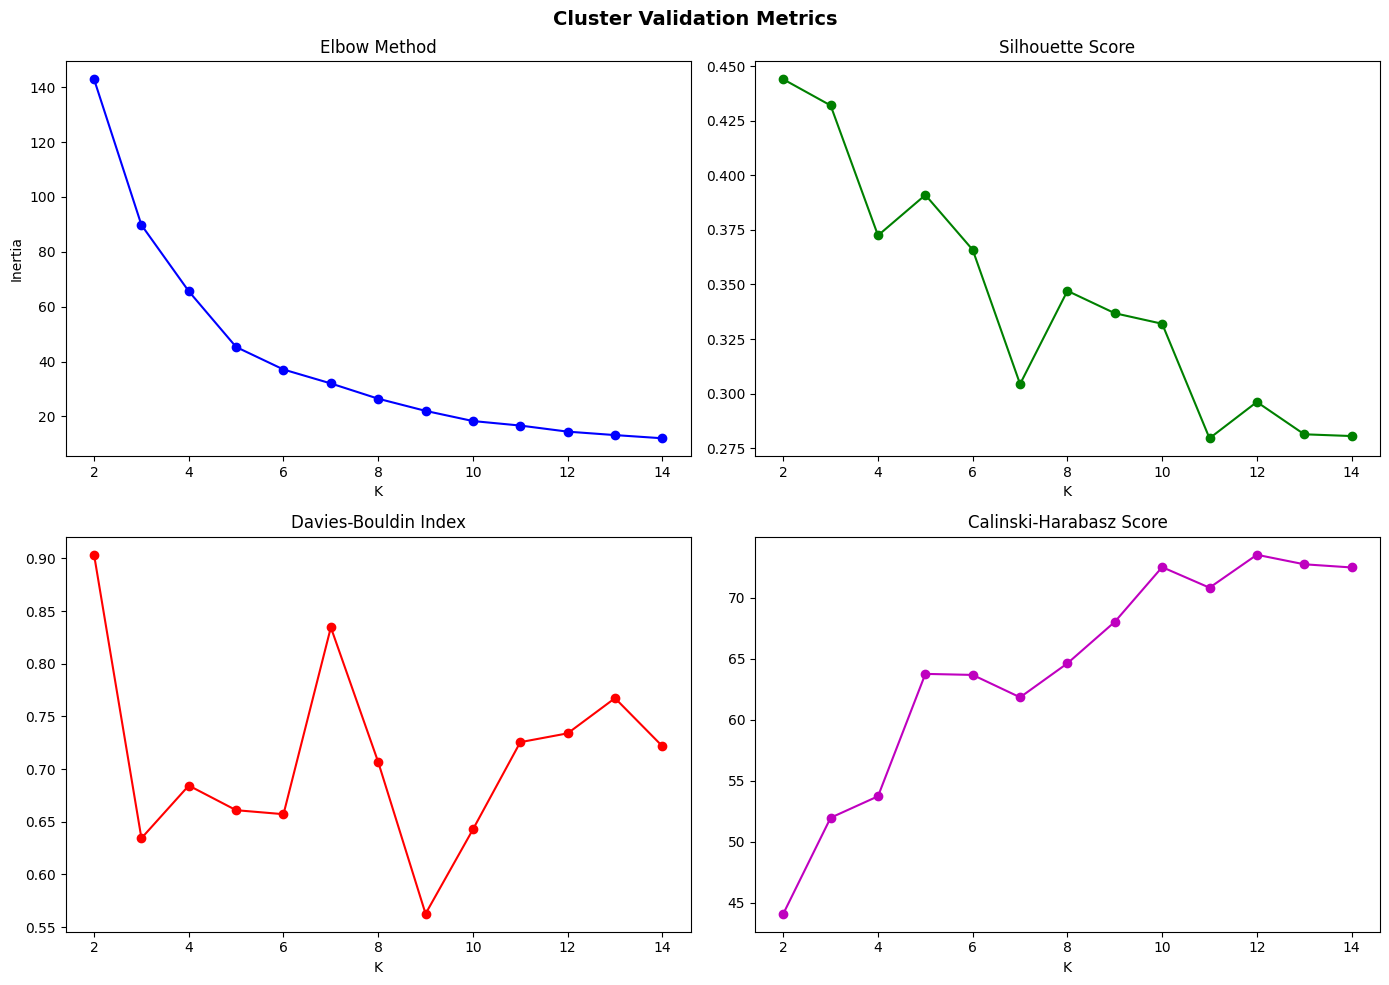

Silhouette best K: 2
Davies-Bouldin best K: 9
Calinski-Harabasz best K: 12


In [ ]:
# Determine optimal K
K_range = range(2, 15)
inertia = []
sil_scores = []
db_scores = []
ch_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X, labels))
    db_scores.append(davies_bouldin_score(X, labels))
    ch_scores.append(calinski_harabasz_score(X, labels))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(K_range, inertia, "bo-")
axes[0, 0].set_title("Elbow Method")
axes[0, 0].set_xlabel("K")
axes[0, 0].set_ylabel("Inertia")

axes[0, 1].plot(K_range, sil_scores, "go-")
axes[0, 1].set_title("Silhouette Score")
axes[0, 1].set_xlabel("K")

axes[1, 0].plot(K_range, db_scores, "ro-")
axes[1, 0].set_title("Davies-Bouldin Index")
axes[1, 0].set_xlabel("K")

axes[1, 1].plot(K_range, ch_scores, "mo-")
axes[1, 1].set_title("Calinski-Harabasz Score")
axes[1, 1].set_xlabel("K")

plt.suptitle("Cluster Validation Metrics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

best_k_sil = list(K_range)[np.argmax(sil_scores)]
best_k_db = list(K_range)[np.argmin(db_scores)]
best_k_ch = list(K_range)[np.argmax(ch_scores)]

print(f"Silhouette best K: {best_k_sil}")
print(f"Davies-Bouldin best K: {best_k_db}")
print(f"Calinski-Harabasz best K: {best_k_ch}")

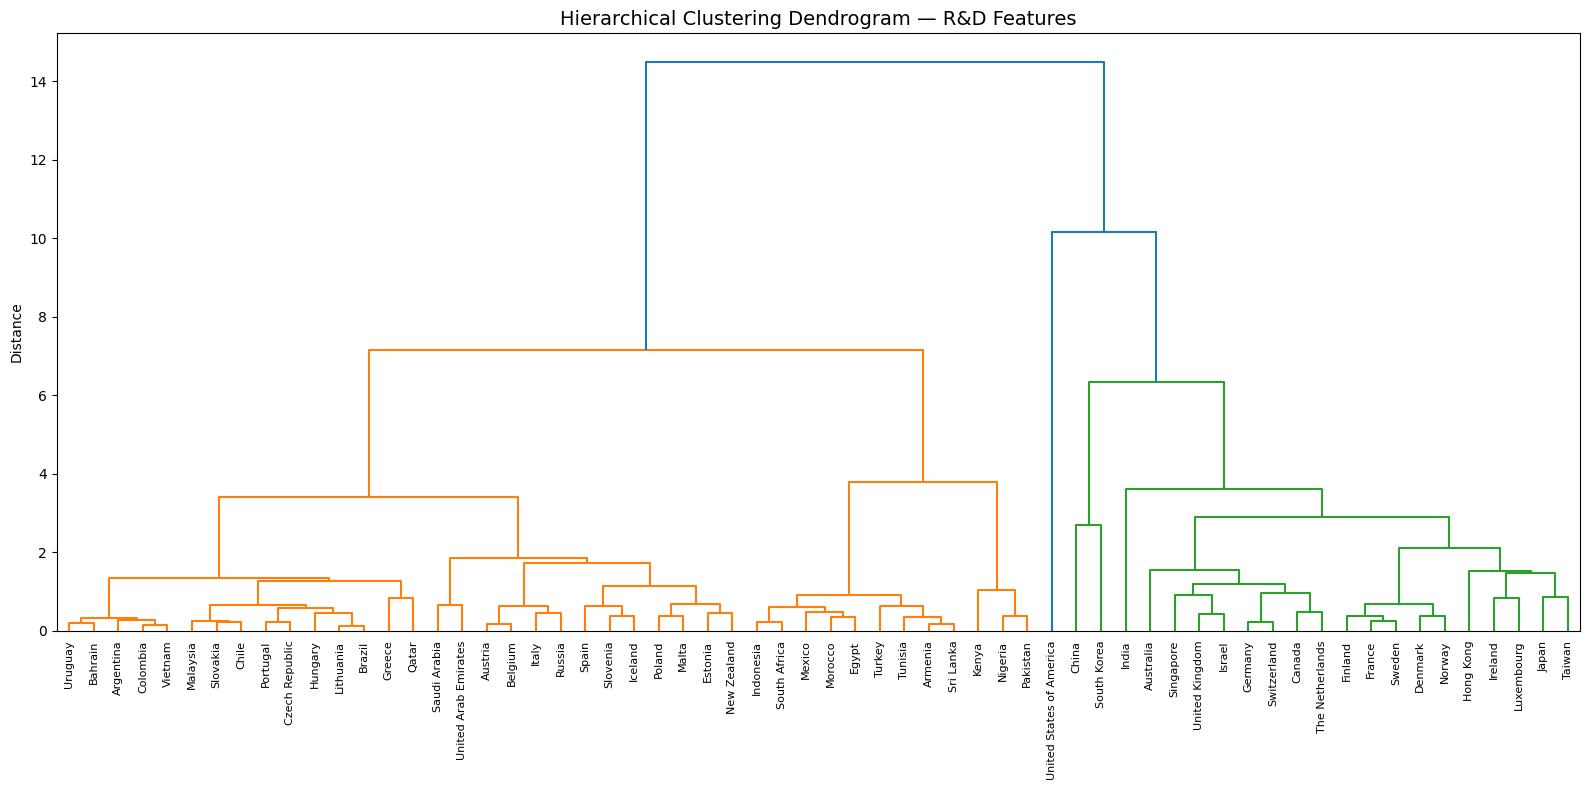

In [ ]:
# Hierarchical clustering
Z = linkage(X, method="ward")

plt.figure(figsize=(16, 8))
dendrogram(Z, labels=ai_index_df["Country"].values, leaf_rotation=90, leaf_font_size=8)
plt.title("Hierarchical Clustering Dendrogram — R&D Features", fontsize=14)
plt.ylabel("Distance")
plt.tight_layout()
plt.show()

In [ ]:
# Assign clusters (use K=5 for interpretable groupings)
best_k = 5
ai_index_df["RD_Cluster"] = fcluster(Z, best_k, criterion="maxclust")

# Summarize clusters
cluster_summary = ai_index_df.groupby("RD_Cluster").agg(
    Countries=("Country", list),
    Count=("Country", "count"),
    Avg_Research=("Research", "mean"),
    Avg_Development=("Development", "mean"),
    Avg_Talent=("Talent", "mean"),
    Avg_RD_Score=("RD_Score", "mean")
).sort_values("Avg_RD_Score", ascending=False)

for _, row in cluster_summary.iterrows():
    print(f"\nCluster (Avg R&D Score: {row['Avg_RD_Score']:.1f}, {row['Count']} countries)")
    print(f"  Research: {row['Avg_Research']:.1f}, Development: {row['Avg_Development']:.1f}, Talent: {row['Avg_Talent']:.1f}")
    countries_str = ", ".join(row["Countries"])
    print(f"  Countries: {countries_str}")


Cluster (Avg R&D Score: 99.1, 1 countries)
  Research: 100.0, Development: 100.0, Talent: 100.0
  Countries: United States of America

Cluster (Avg R&D Score: 57.7, 2 countries)
  Research: 49.0, Development: 78.6, Talent: 15.5
  Countries: China, South Korea

Cluster (Avg R&D Score: 33.9, 19 countries)
  Research: 27.9, Development: 23.4, Talent: 28.2
  Countries: United Kingdom, Canada, Israel, Singapore, The Netherlands, Germany, France, Australia, Ireland, Finland, Denmark, Luxembourg, Japan, India, Switzerland, Sweden, Hong Kong, Taiwan, Norway

Cluster (Avg R&D Score: 17.3, 28 countries)
  Research: 9.7, Development: 6.5, Talent: 11.3
  Countries: Spain, Austria, Estonia, Saudi Arabia, Belgium, Poland, Slovenia, New Zealand, Italy, Russia, Malta, United Arab Emirates, Portugal, Czech Republic, Iceland, Lithuania, Brazil, Greece, Slovakia, Hungary, Malaysia, Chile, Argentina, Qatar, Colombia, Uruguay, Bahrain, Vietnam

Cluster (Avg R&D Score: 7.6, 12 countries)
  Research: 2.5, D

In [ ]:
# Find Canada's cluster and peers
canada_cluster = ai_index_df[ai_index_df["Country"] == "Canada"]["RD_Cluster"].values[0]
canada_peers = ai_index_df[ai_index_df["RD_Cluster"] == canada_cluster][["Country", "RD_Score"]]
canada_peers = canada_peers.sort_values("RD_Score", ascending=False)

print(f"Canada is in Cluster {canada_cluster}")
print(f"\nCanada's cluster peers (sorted by R&D Score):")
print(canada_peers.to_string(index=False))

Canada is in Cluster 4

Canada's cluster peers (sorted by R&D Score):
        Country  RD_Score
      Singapore   40.4705
 United Kingdom   38.9285
      Australia   38.3660
    Switzerland   37.2075
         Israel   37.0975
        Germany   37.0900
The Netherlands   37.0545
         Canada   36.2820
        Ireland   34.5425
          Japan   33.9425
         France   32.5865
         Sweden   31.9270
      Hong Kong   31.5460
     Luxembourg   31.3355
        Finland   30.0575
          India   30.0205
         Taiwan   29.1425
         Norway   28.4330
        Denmark   28.3055


---
## Key Findings & Strategy Implications (Part 2)

### Summary of Canada's R&D Position

Based on our analysis of the AI Index Report 2025 Chapter 1 data, Canada's R&D position can be characterized as follows:

**Strengths:**
- **High-impact research:** Canada consistently appears in the top 10 for most-cited AI publications (6 papers in the top 100 in 2023), suggesting strong research quality despite lower overall volume
- **Strong government strategy:** Canada scores 100/100 on the Tortoise Media Government Strategy indicator, the highest of any country
- **Talent pipeline:** Canada scores 31.28 on Talent, supported by leading AI research institutions (University of Toronto, Mila, University of Montreal)

**Weaknesses:**
- **Negligible patent output:** Canada ranks 18th in AI patents per capita (0.17 per 100K), roughly 30x lower than the US and 100x lower than South Korea. Canada is not individually tracked in the AI Index patent data
- **Minimal notable AI model production:** Only 1 notable AI model from Canada in 2024, compared to 40 from the US and 15 from China
- **Low publication volume:** Canada's total publication output is too small to be tracked as a separate country in the AI Index
- **Industry-academia gap:** With 90% of notable AI models now coming from industry, Canada's academic-heavy AI ecosystem is not producing frontier systems

### Strategy Recommendations from R&D Analysis

1. **Incentivize AI patent commercialization:** Canada's research quality is not translating into commercial IP. Programs such as enhanced SR&ED tax credits for AI-related patent filings, or dedicated patent support services for AI startups, could help close this gap.

2. **Scale industry R&D capacity:** Since 90% of notable AI models now come from industry, Canada needs to attract and grow AI companies capable of frontier model development. The \$2B Canadian Sovereign AI Compute Strategy addresses compute, but should be paired with industry R&D co-funding mechanisms such as expanded Mitacs Accelerate placements targeting AI firms.

3. **Leverage research quality through open-source strategy:** Canada punches above its weight in citation impact. An open-source-first approach to publicly funded AI research, similar to China's strategy with DeepSeek and Qwen, could amplify Canada's global research influence and attract international collaboration.

4. **Strengthen industry-academia collaboration:** The US has a 16.5% industry share of AI publications compared to China's 8.0%. Programs that incentivize joint industry-academia research, such as expanding Mitacs placements with AI-specific streams and reducing application timelines, could help bridge this gap.

---
## Part 3: Practical Steps for Implementing AI Strategy

### Enhancing the Mitacs Research Internship Program for AI

Mitacs is a national not-for-profit innovation organization that connects post-secondary students, postdocs, and recent graduates with industry partners through paid research placements. In 2023-24, Mitacs leveraged over \$154 million in federal support into more than \$318 million in R&D investment, delivering over 19,400 internships. For 2024-25, Mitacs reported 20,885 internships through 7,202 projects.

Mitacs is strategically useful for AI policy because it already solves several coordination problems: it lowers the cost of matching researchers and firms, addresses the AI commercialization gap between strong university research and weak firm adoption, improves employability and talent retention, and has demonstrated measurable economic impact. A Statistics Canada study found that participating firms showed average gains of 9% in revenue, 16% in sales, and 11% in labour productivity by the third year after support.

Below we analyze the key Mitacs programs, identify weaknesses relevant to AI strategy, and propose specific enhancements.

### Current Mitacs Programs Relevant to AI

| Program | Duration | Funding Model | AI Relevance |
|---|---|---|---|
| **Accelerate** | 4-6 months (extendable) | \$15,000 per unit (\$7,500 partner + \$7,500 Mitacs match). Intern receives min \$10,000 stipend | Primary mechanism for moving AI talent from labs to firms. Supports applied research, prototyping, commercialization |
| **Business Strategy Internship (BSI)** | 4 months | \$10,000-\$15,000 per intern (\$5,000-\$7,500 partner match) | Useful for AI adoption, commercialization, non-technical scaling |
| **Globalink Research Internship (GRI)** | 12 weeks | Covers travel and living costs | International talent pipeline and attraction tool |
| **Accelerate International / Globalink Research Award** | Varies | Bilateral mobility support | International collaboration, bringing global AI talent into Canadian projects |

### Identified Weaknesses

1. **Broad, not AI-specific:** Mitacs is a horizontal innovation platform. Nothing in the core Accelerate model guarantees support for high-priority AI fields like compute-efficient models, AI safety, medical AI, or defence AI. AI may not receive strategic targeting unless government adds mission-oriented streams.

2. **Firm absorptive capacity:** Many Small and Medium-sized Enterprises lack the capacity to scope a good AI internship project. Innovation, Science and Economic Development Canada's evaluation notes that lack of awareness is an obstacle for some talent pathways, and Mitacs has had to build partnerships to increase awareness.

3. **Slow application and review timelines:** Peer review can take 6 to 8 weeks. In AI, firms often move faster than traditional academic cycles. This creates a mismatch between industry urgency and program processing speed.

4. **Retention gaps:** Mitacs helps firms test talent and often leads to hiring, but the placement itself does not guarantee that graduates stay in Canada or continue in the AI sector. This is especially relevant for a strategy emphasizing talent retention.

5. **Decentralized IP rules:** Mitacs does not take a position on IP ownership; IP is determined by the institution's policies or separate agreements. For AI commercialization this can create friction, uncertainty, and uneven incentives for firms.

| Weakness | Description | Linked R&D Gap |
|---|---|---|
| Broad, not AI-specific | Nothing in the core Accelerate model guarantees support for high-priority AI fields | Low notable AI model production |
| Low firm awareness | Many SMEs lack absorptive capacity to scope AI internship projects | Industry-academia gap |
| Slow review timelines | Peer review takes 6-8 weeks; AI firms often move faster | Industry-academia gap |
| No built-in retention mechanism | Placement does not guarantee graduates stay in Canada or in AI | Talent retention |
| Decentralized IP rules | IP ownership determined by individual institution policies, creating friction | Low patent output |

### Proposed Enhancements to Mitacs for AI Strategy

Each recommendation includes estimated cost, implementation timeline, responsible ministry or agency, and a metric for measuring success.

**Federal budget context:** In 2024-25, total federal expenses were \$547.3B, with revenues of \$511.0B and a deficit of \$36.3B ([Annual Financial Report 2025](https://www.canada.ca/en/department-finance/services/publications/annual-financial-report/2025.html)). The 2025-26 Main Estimates show \$486.9B in planned budgetary spending, with ISED at \$8.6B and ESDC at \$105.7B ([2025-26 Main Estimates](https://www.canada.ca/en/treasury-board-secretariat/services/planned-government-spending/government-expenditure-plan-main-estimates/2025-26-estimates.html)). Mitacs reported leveraging over \$166M in federal dollars into more than \$345M in R&D investment in 2024-25 (Mitacs Annual Report 2024-25).

Note: Throughout this section, "SMEs" refers to enterprises with 1 to 499 paid employees, per the ISED definition ([Key Small Business Statistics 2023](https://ised-isde.canada.ca/site/sme-research-statistics/en/key-small-business-statistics/key-small-business-statistics-2023)).

**1. Create an AI-specific Accelerate stream**

Introduce a dedicated Mitacs Accelerate stream for AI projects in priority areas (AI safety, medical AI, compute-efficient models, natural resource optimization). This stream would have higher funding caps to reflect the compute costs of AI research and could include access to the Canadian Sovereign AI Compute infrastructure, which Budget 2024 funded at \$2B over five years ([Sovereign AI Compute Strategy](https://ised-isde.canada.ca/site/ised/en/canadian-sovereign-ai-compute-strategy)).

- **Estimated cost:** \$10-25M per year. Current Mitacs Accelerate units cost \$15,000 each (\$7,500 partner match + \$7,500 Mitacs match). At that rate, \$10-25M funds approximately 700-1,700 additional AI-specific placements, which is 6-15% of Mitacs' existing federal support (\$166M).
- **Timeline:** 1-2 years. Mitacs already has the Accelerate program infrastructure. The main work is defining AI priority areas, establishing selection criteria, and securing a Treasury Board submission for the new funding stream. Comparable new streams within existing federal programs typically take 12-18 months from announcement to first intake.
- **Responsible agency:** ISED (2025-26 budget: \$8.6B) in collaboration with Mitacs and CIFAR
- **Success metric:** Number of AI-specific Accelerate placements per year

**2. AI readiness advisory service for SMEs**

Many SMEs want to adopt AI but cannot scope an internship project because they lack in-house AI expertise. Create a pre-placement advisory service that helps firms identify AI use cases and formulate project proposals before applying to Accelerate. This builds on the existing NRC Industrial Research Assistance Program (IRAP) model, which already provides advisory services through a national network of Industrial Technology Advisors ([NRC-IRAP](https://nrc.canada.ca/en/support-technology-innovation)).

- **Estimated cost:** \$3-5M per year. NRC-IRAP already operates a network of approximately 250 Industrial Technology Advisors across Canada. Adding 30-50 AI-focused advisors embedded in Mitacs business development teams, at approximately \$100K per advisor (salary, benefits, overhead, and travel, consistent with federal professional staffing costs), yields \$3-5M.
- **Timeline:** 1 year to pilot in 2-3 regions, 2 years for national rollout. NRC-IRAP's existing regional structure provides the operational model; the pilot phase involves recruiting advisors and establishing referral pathways with Mitacs, which can begin within an existing fiscal year.
- **Responsible agency:** Mitacs with support from NRC-IRAP
- **Success metric:** Number of first-time SME applicants to Mitacs AI programs per year

**3. Fast-track review process for AI projects**

Reduce the peer review timeline from 6-8 weeks to 2 weeks for AI Accelerate applications by maintaining a standing panel of AI reviewers and using a streamlined assessment rubric focused on feasibility, partner capacity, and alignment with AI strategy priorities.

- **Estimated cost:** Minimal incremental cost. Canadian federal peer review is primarily volunteer-based under the Tri-Council Joint Policy on Peer/Merit Review Financial Recompense, which states that peer review is "first and foremost" a volunteer system ([Joint Policy](https://science.gc.ca/site/science/en/interagency-research-funding/policies-and-guidelines/joint-policy-peermerit-review-financial-recompense)). CIHR provides a \$50/day virtual meeting allowance ([CIHR Peer Review Allowance](https://cihr-irsc.gc.ca/e/52663.html)). The main cost would be administrative coordination: 2-3 additional staff at Mitacs to manage the standing panel and expedite processing, approximately \$200-400K per year.
- **Timeline:** 6-12 months. This is an operational change within Mitacs, not a new program requiring Treasury Board approval. It involves recruiting a standing reviewer panel, developing a streamlined rubric, and modifying internal workflows.
- **Responsible agency:** Mitacs
- **Success metric:** Median application-to-approval time for AI stream applications

**4. Post-placement retention incentives**

Offer a retention bonus to partner organizations that hire their Mitacs AI interns into permanent roles within 6 months of placement completion. This could take the form of a wage subsidy (e.g., 25% of salary for the first year) or a follow-on R&D grant conditional on continued employment. Statistics Canada data shows participating Mitacs firms already see 18% employment growth over seven years (Mitacs Annual Report 2024-25), so this would reinforce an existing positive trend.

- **Estimated cost:** \$5-10M per year. Assuming 500-1,000 AI intern conversions at \$10,000 per retention incentive. The \$10,000 figure is consistent with the existing BSI internship unit size. For context, ESDC's 2025-26 budget is \$105.7B ([2025-26 Main Estimates](https://www.canada.ca/en/treasury-board-secretariat/services/planned-government-spending/government-expenditure-plan-main-estimates/2025-26-estimates.html)).
- **Timeline:** 1-2 years. Requires policy design (eligibility criteria, verification of permanent hire status, payment mechanism) and a pilot cohort. Similar wage subsidy programs like the Canada Summer Jobs program provide an operational precedent for employer-directed subsidies administered through ESDC.
- **Responsible agency:** ISED and ESDC
- **Success metric:** Percentage of Mitacs AI interns hired into permanent roles within 12 months of placement completion

**5. Standardized AI IP framework**

Develop a model AI IP agreement template that Mitacs partner institutions can adopt, providing clear default terms for ownership, licensing, and commercialization rights for AI-generated IP. This addresses the current friction where IP is left entirely to institutional policies.

- **Estimated cost:** \$500K-1M one-time. This covers legal research, multi-stakeholder consultation (universities, industry, Mitacs, IP professionals), drafting, and pilot testing. For comparison, ISED's total 2025-26 budget is \$8.6B ([2025-26 Main Estimates](https://www.canada.ca/en/treasury-board-secretariat/services/planned-government-spending/government-expenditure-plan-main-estimates/2025-26-estimates.html)).
- **Timeline:** 1 year for development, 2 years for voluntary adoption across institutions. IP policy changes in universities require governance approval (senate, board), which typically operates on annual cycles.
- **Responsible agency:** ISED in collaboration with Universities Canada and the Intellectual Property Institute of Canada
- **Success metric:** Percentage of Mitacs AI placements using the standardized IP framework

### Summary of Proposed Enhancements

| Enhancement | Est. Annual Cost | Timeline | Responsible Agency | Success Metric |
|---|---|---|---|---|
| AI-specific Accelerate stream | \$10-25M | 1-2 years | ISED / Mitacs / CIFAR | AI-specific placements/year |
| AI readiness advisory for SMEs | \$3-5M | 1-2 years | Mitacs / NRC-IRAP | First-time SME applicants/year |
| Fast-track review (2 weeks) | \$200-400K | 6-12 months | Mitacs | Median approval time |
| Post-placement retention incentives | \$5-10M | 1-2 years | ISED / ESDC | % interns hired permanently |
| Standardized AI IP framework | \$500K-1M (one-time) | 1-2 years | ISED / Universities Canada | % placements using framework |
| **Total** | **\$18-40M/year** | | | |

The total estimated incremental cost of these Mitacs enhancements is approximately \$18 to \$40 million per year, plus a one-time \$500K-1M for the IP framework. For context, Mitacs currently receives over \$166M in federal support annually (Mitacs Annual Report 2024-25), so these proposals represent a roughly 11-24% increase in federal investment in the program. Relative to total federal expenses of \$547.3B in 2024-25 ([Annual Financial Report 2025](https://www.canada.ca/en/department-finance/services/publications/annual-financial-report/2025.html)), the entire package is less than 0.01% of the budget.

The enhancements are designed to address the specific R&D weaknesses identified in our analysis: Canada's low patent output (addressed by the IP framework and retention incentives), minimal industry AI model production (addressed by the AI-specific stream and SME advisory service), and the industry-academia gap (addressed by faster review processes and retention incentives that encourage firms to invest in AI talent through Mitacs).